
# QKD Intrusion Detection: LSTM & ML vs Static QBER Threshold

This notebook trains and evaluates models to detect eavesdropping attacks
(photon-number-splitting / PNS and intercept-resend / IR) on simulated
decoy-state BB84 QKD telemetry, and compares them against a static
QBER-threshold baseline.

**Context from the EDA (see the project's `eda_qkd.py` / `eda_within_run.py`
reports) that this notebook's design choices are based on:**
- Raw/pooled feature magnitudes are confounded by cross-run distance and
  hardware differences (runs span 5-80 km, two hardware profiles). A feature
  like `y1_lower` correlates ~0.99 with `n_sifted` in the pooled data purely
  from run geometry, masking its real attack signal (pooled AUC vs PNS ~0.50
  vs ~0.89 after per-run normalization). **This notebook normalizes every
  feature per-run before using it for anything.**
- Normalization here uses **robust per-run statistics (median / MAD) computed
  over each run's entire time series**, not label-based. This is
  deliberately different from the EDA's oracle-informed (label==0-based)
  diagnostic baseline -- a real detector doesn't get to see which ticks are
  clean in advance. Median/MAD is robust to the ~8% attack contamination
  fraction, so this is a defensible, deployable approximation.
- PNS attack severity varies continuously (`attack_strength_instant` ~
  Uniform(0.01, 0.15)), which is why a single static threshold structurally
  struggles even on features with good AUC (bimodal separation: weak attacks
  overlap clean, strong attacks are well separated). This motivates a model
  over a fixed cutoff.
- `yield_ratio` and `decoy_anomaly` are perfectly anti-correlated (linear
  transform of each other) -- only one is kept as a model input.

**What this notebook produces:** a trained LSTM, two tabular ML baselines
(Logistic Regression, Random Forest) trained on the same windows for a fair
comparison, and a recomputed static-QBER-threshold baseline -- all evaluated
on the held-out test set (uncooled hardware, unseen at training time) and
broken down separately by attack type (PNS vs IR), since that split is the
actual point of this project.

**Environment assumptions:** Google Colab free tier, T4 GPU runtime.
Dataset (`qkd_train_decoy.csv`, `qkd_test_decoy.csv`, ~1.1 GB each) expected
at `MyDrive/Capstone/`. Runtime -> Change runtime type -> T4 GPU, before
running this notebook.


## 1. Setup

In [1]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:

!pip install -q torch scikit-learn pandas numpy matplotlib


In [3]:

import os
import time
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_recall_curve,
    confusion_matrix, classification_report,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected. Runtime -> Change runtime type -> T4 GPU, then re-run.")


device: cuda
GPU: Tesla T4



## 2. Load data

Google Drive-mounted file I/O is slow for large sequential reads (pandas
parsing a 1+ GB CSV directly off Drive can take much longer than off local
disk). We copy both CSVs to local Colab disk first, then read from there.

Dtypes are specified up front in `read_csv` (rather than loading as float64
and downcasting after) to keep peak memory low -- this matters on the free
tier's limited system RAM.


In [4]:

DRIVE_DIR = "/content/drive/MyDrive/Capstone"
LOCAL_DIR = "/content/qkd_data"
os.makedirs(LOCAL_DIR, exist_ok=True)

for fname in ["qkd_train_decoy.csv", "qkd_test_decoy.csv"]:
    src = os.path.join(DRIVE_DIR, fname)
    dst = os.path.join(LOCAL_DIR, fname)
    if not os.path.exists(dst):
        print(f"copying {fname} to local disk...")
        shutil.copy(src, dst)
    else:
        print(f"{fname} already local, skipping copy")
print("done")


copying qkd_train_decoy.csv to local disk...
copying qkd_test_decoy.csv to local disk...
done


In [5]:

DTYPE_MAP = {
    "run_id": "int32", "tick": "int32", "hardware": "category", "run_type": "category",
    "distance_km": "float32", "n_sifted": "int32", "observed_qber": "float32",
    "attack_kind": "category", "attack_strength_instant": "float32", "label": "int8",
    "yield_signal": "float32", "yield_decoy": "float32", "yield_vacuum": "float32",
    "qber_signal": "float32", "qber_decoy": "float32", "qber_delta": "float32",
    "yield_ratio": "float32", "decoy_anomaly": "float32", "y1_lower": "float32",
    "e1_upper": "float32", "secure_key_rate": "float32",
    "qber_roll_mean_30": "float32", "qber_roll_std_30": "float32", "qber_slope_30": "float32",
    "sifted_rate_roll_mean_30": "float32", "qber_roll_mean_60": "float32",
    "qber_roll_mean_120": "float32", "qber_roll_std_60": "float32", "qber_roll_std_120": "float32",
    "qber_cv_30": "float32", "yield_ratio_roll_mean_30": "float32",
    "yield_ratio_roll_std_30": "float32", "decoy_anomaly_roll_mean_30": "float32",
    "y1_lower_roll_mean_30": "float32", "secure_key_rate_roll_mean_30": "float32",
    "secure_key_rate_roll_std_30": "float32",
}

t0 = time.time()
train_df = pd.read_csv(os.path.join(LOCAL_DIR, "qkd_train_decoy.csv"), dtype=DTYPE_MAP)
test_df  = pd.read_csv(os.path.join(LOCAL_DIR, "qkd_test_decoy.csv"), dtype=DTYPE_MAP)
print(f"loaded in {time.time()-t0:.1f}s  train={train_df.shape}  test={test_df.shape}")
print(f"memory: train={train_df.memory_usage(deep=True).sum()/1e9:.2f} GB, "
      f"test={test_df.memory_usage(deep=True).sum()/1e9:.2f} GB")

assert train_df["hardware"].unique().tolist() == ["cooled"], "expected train = cooled hardware only"
assert test_df["hardware"].unique().tolist() == ["uncooled"], "expected test = uncooled hardware only"
print("train/test hardware split confirmed (cooled -> uncooled domain shift, as designed)")


loaded in 78.3s  train=(4320000, 36)  test=(4320000, 36)
memory: train=0.57 GB, test=0.57 GB
train/test hardware split confirmed (cooled -> uncooled domain shift, as designed)



## 3. Feature selection

Dropped, based on the EDA's correlation analysis:
- `yield_ratio*` (perfectly anti-correlated with `decoy_anomaly*`, r = -1.00 -- redundant)
- raw (non-rolled) `decoy_anomaly`, `y1_lower` (dominated by shot noise per-tick; the rolled
  versions carry the usable signal)
- `qber_roll_mean_60` / `_120` and their std variants (redundant with the `_30` window,
  kept lean for a first pass -- feel free to add these back and re-run)

Kept: raw `observed_qber` (so the model can see instantaneous noise level, not just
the smoothed trend), the 30-tick rolled QBER stats, the rolled decoy/Y1/key-rate
features, and `sifted_rate_roll_mean_30` (throughput, itself informative since PNS
suppresses single-photon yield).


In [6]:

FEATURE_COLS = [
    "observed_qber", "qber_roll_mean_30", "qber_roll_std_30", "qber_cv_30", "qber_slope_30",
    "decoy_anomaly_roll_mean_30", "y1_lower_roll_mean_30",
    "secure_key_rate_roll_mean_30", "sifted_rate_roll_mean_30",
]
print(f"{len(FEATURE_COLS)} input features:", FEATURE_COLS)


9 input features: ['observed_qber', 'qber_roll_mean_30', 'qber_roll_std_30', 'qber_cv_30', 'qber_slope_30', 'decoy_anomaly_roll_mean_30', 'y1_lower_roll_mean_30', 'secure_key_rate_roll_mean_30', 'sifted_rate_roll_mean_30']



## 4. Per-run robust normalization

For each run, subtract that run's own median and divide by that run's own
MAD (median absolute deviation, scaled by 1.4826 to be std-comparable for
normal data) -- computed from **every tick in the run, not just clean ticks**.
Median/MAD are robust to the ~8% attack contamination, so this stays close to
a "clean baseline" without needing oracle label knowledge, unlike the EDA's
diagnostic z-score. This removes the cross-run distance/hardware confound
that the EDA showed was masking real attack signal in the pooled data.

Values are clipped to [-10, 10] to bound the effect of any single extreme
outlier tick on the LSTM's input scale.


In [7]:

def robust_normalize_per_run(df, feature_cols):
    df = df.sort_values(["run_id", "tick"]).reset_index(drop=True)
    med = df.groupby("run_id", observed=True)[feature_cols].transform("median")
    mad = (df[feature_cols] - med).abs()
    mad = mad.groupby(df["run_id"], observed=True).transform("median")
    scale = 1.4826 * mad + 1e-6
    z = (df[feature_cols] - med) / scale
    z = z.clip(-10, 10)
    for c in feature_cols:
        df[c + "_z"] = z[c].astype(np.float32)
    return df

t0 = time.time()
train_df = robust_normalize_per_run(train_df, FEATURE_COLS)
test_df  = robust_normalize_per_run(test_df, FEATURE_COLS)
print(f"normalized in {time.time()-t0:.1f}s")

Z_COLS = [c + "_z" for c in FEATURE_COLS]
train_df[Z_COLS].describe().T[["mean", "std", "min", "max"]]


normalized in 13.1s


,mean,std,min,max
observed_qber_z,0.306936,1.930329,-4.066825,10.000000
qber_roll_mean_30_z,0.338261,2.077338,-8.514907,10.000000
qber_roll_std_30_z,0.199400,1.537098,-7.580496,10.000000
qber_cv_30_z,-0.036119,1.136030,-7.666829,10.000000
qber_slope_30_z,0.000167,1.056188,-10.000000,10.000000
decoy_anomaly_roll_mean_30_z,-0.024953,1.019063,-10.000000,9.862642
y1_lower_roll_mean_30_z,-0.102072,1.298945,-10.000000,10.000000
secure_key_rate_roll_mean_30_z,0.086974,0.883546,-0.668812,10.000000
sifted_rate_roll_mean_30_z,-0.288694,1.928232,-10.000000,10.000000



## 5. Windowing

Each LSTM input is a `WINDOW_LEN`-tick sequence of normalized features; the
label is the **last tick's** label (real-time framing: "is the system under
attack right now, given the last `WINDOW_LEN` seconds of context"). Windows
never cross a run boundary. `STRIDE` controls overlap between consecutive
windows -- lower stride = more windows (denser training signal, more
compute); the defaults below keep the full-dataset window count in the
hundreds of thousands, which is comfortable for a T4 session.

Tune `WINDOW_LEN` / `STRIDE` here if you want to experiment.


In [8]:

WINDOW_LEN = 60
STRIDE = 30

def build_windows(df, feature_cols, window_len, stride):
    feat = df[feature_cols].values.astype(np.float32)
    label = df["label"].values.astype(np.float32)
    attack_kind = df["attack_kind"].values
    run_id = df["run_id"].values

    run_boundaries = np.flatnonzero(np.diff(run_id) != 0) + 1
    run_starts = np.concatenate([[0], run_boundaries])
    run_ends = np.concatenate([run_boundaries, [len(run_id)]])

    starts_list = []
    for s, e in zip(run_starts, run_ends):
        n = e - s
        if n < window_len:
            continue
        local_starts = np.arange(0, n - window_len + 1, stride)
        starts_list.append(s + local_starts)
    starts = np.concatenate(starts_list)
    ends = starts + window_len
    win_labels = label[ends - 1]
    win_attack_kind = attack_kind[ends - 1]
    win_run_id = run_id[ends - 1]
    return feat, starts, ends, win_labels, win_attack_kind, win_run_id

t0 = time.time()
train_feat, train_starts, train_ends, train_labels, train_ak, train_rid = build_windows(
    train_df, Z_COLS, WINDOW_LEN, STRIDE
)
test_feat, test_starts, test_ends, test_labels, test_ak, test_rid = build_windows(
    test_df, Z_COLS, WINDOW_LEN, STRIDE
)
print(f"windowed in {time.time()-t0:.1f}s")
print(f"train windows: {len(train_starts):,}   test windows: {len(test_starts):,}")
print(f"train positive frac: {train_labels.mean():.4f}   test positive frac: {test_labels.mean():.4f}")


windowed in 0.7s
train windows: 143,950   test windows: 143,950
train positive frac: 0.0857   test positive frac: 0.0752


## 6. Dataset, train/val split, DataLoaders

In [9]:

class QKDWindowDataset(Dataset):
    '''Lazily slices windows from the full per-tick feature array -- no
    per-window data duplication, so this stays memory-light even with
    hundreds of thousands of windows.'''
    def __init__(self, feat, starts, ends, labels):
        self.feat = feat
        self.starts = starts
        self.ends = ends
        self.labels = labels

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        s, e = self.starts[idx], self.ends[idx]
        x = self.feat[s:e]
        y = self.labels[idx]
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.float32)


In [10]:

# Hold out ~20% of TRAIN run_ids (not rows -- avoids leaking adjacent ticks
# of the same run between train and val) for validation / early stopping.
rng = np.random.default_rng(SEED)
train_run_ids = np.unique(train_rid)
val_run_ids = rng.choice(train_run_ids, size=max(1, len(train_run_ids) // 5), replace=False)
is_val = np.isin(train_rid, val_run_ids)

tr_ds = QKDWindowDataset(train_feat, train_starts[~is_val], train_ends[~is_val], train_labels[~is_val])
va_ds = QKDWindowDataset(train_feat, train_starts[is_val], train_ends[is_val], train_labels[is_val])
te_ds = QKDWindowDataset(test_feat, test_starts, test_ends, test_labels)

print(f"train/val/test windows: {len(tr_ds):,} / {len(va_ds):,} / {len(te_ds):,}")

BATCH_SIZE = 256
tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
va_loader = DataLoader(va_ds, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
te_loader = DataLoader(te_ds, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)


train/val/test windows: 115,160 / 28,790 / 143,950


## 7. LSTM model

In [11]:

class LSTMDetector(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden_size, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_layer_hidden = h_n[-1]           # (batch, hidden_size)
        return self.head(last_layer_hidden).squeeze(-1)   # logits

model = LSTMDetector(n_features=len(Z_COLS)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"model params: {n_params:,}")


model params: 54,593



## 8. Training

Class imbalance (~8% positive) is handled with `pos_weight` in
`BCEWithLogitsLoss` rather than resampling, so every epoch still sees the
real data distribution. Mixed precision (`torch.autocast` + `GradScaler`) is
enabled automatically on GPU for T4 throughput; it's a no-op on CPU. Best
checkpoint (by validation AUC) is saved to Drive so it survives a session
disconnect.


In [12]:

N_EPOCHS = 15
PATIENCE = 3
LR = 1e-3
CKPT_PATH = os.path.join(DRIVE_DIR, "best_lstm_model.pt")

pos_frac = train_labels[~is_val].mean()
pos_weight = torch.tensor([(1 - pos_frac) / pos_frac], device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
opt = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=1)
scaler = torch.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

def run_eval_loader(model, loader):
    model.eval()
    logits, ys = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            out = model(xb).float().cpu().numpy()
            logits.append(out)
            ys.append(yb.numpy())
    return np.concatenate(logits), np.concatenate(ys)

best_val_auc = -1.0
best_state = None
bad_epochs = 0
history = {"train_loss": [], "val_auc": []}

for epoch in range(N_EPOCHS):
    model.train()
    t0 = time.time()
    train_loss = 0.0
    for xb, yb in tr_loader:
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        opt.zero_grad()
        with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
            out = model(xb)
            loss = criterion(out, yb)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        train_loss += loss.item() * len(yb)
    train_loss /= len(tr_ds)

    val_logits, val_y = run_eval_loader(model, va_loader)
    val_auc = roc_auc_score(val_y, val_logits)
    scheduler.step(val_auc)

    history["train_loss"].append(train_loss)
    history["val_auc"].append(val_auc)
    print(f"epoch {epoch+1:2d}/{N_EPOCHS}  train_loss={train_loss:.4f}  "
          f"val_auc={val_auc:.4f}  time={time.time()-t0:.1f}s")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, CKPT_PATH)
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"early stopping at epoch {epoch+1} (no val improvement for {PATIENCE} epochs)")
            break

model.load_state_dict(best_state)
print(f"\nbest val AUC: {best_val_auc:.4f}  (checkpoint saved to {CKPT_PATH})")


epoch  1/15  train_loss=0.2895  val_auc=0.9838  time=6.0s
epoch  2/15  train_loss=0.2205  val_auc=0.9854  time=4.6s
epoch  3/15  train_loss=0.2116  val_auc=0.9846  time=6.6s
epoch  4/15  train_loss=0.2020  val_auc=0.9845  time=4.0s
epoch  5/15  train_loss=0.1945  val_auc=0.9842  time=4.2s
early stopping at epoch 5 (no val improvement for 3 epochs)

best val AUC: 0.9854  (checkpoint saved to /content/drive/MyDrive/Capstone/best_lstm_model.pt)


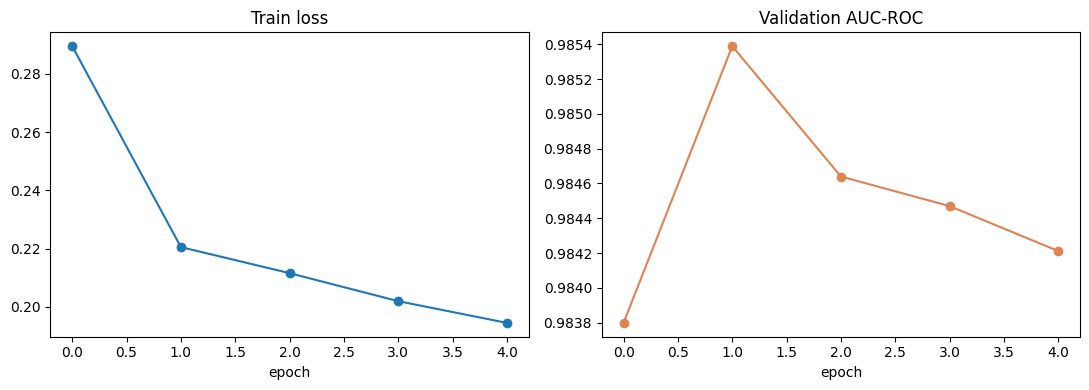

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["train_loss"], marker="o")
axes[0].set_title("Train loss")
axes[0].set_xlabel("epoch")
axes[1].plot(history["val_auc"], marker="o", color="#dd8452")
axes[1].set_title("Validation AUC-ROC")
axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()



## 9. Evaluation on held-out test set (unseen uncooled hardware)

Evaluated **overall** and separately on **PNS-only** and **IR-only** subsets
(each vs the clean ticks) -- this breakdown is the actual point of the
project: whether the model closes the gap on PNS specifically, where a
static QBER threshold is theoretically weakest.


In [14]:

def evaluate_probs(probs, y, attack_kind_arr, threshold=0.5):
    results = {}
    for name, ak_mask in [
        ("ALL", np.ones(len(y), dtype=bool)),
        ("PNS_only", np.isin(attack_kind_arr, ["none", "pns_like"])),
        ("IR_only", np.isin(attack_kind_arr, ["none", "intercept_resend"])),
    ]:
        yy, pp = y[ak_mask], probs[ak_mask]
        if len(np.unique(yy)) < 2:
            results[name] = None
            continue
        auc = roc_auc_score(yy, pp)
        ap = average_precision_score(yy, pp)
        f1 = f1_score(yy, (pp > threshold).astype(int))
        results[name] = dict(auc=auc, ap=ap, f1=f1, n=len(yy), pos=int(yy.sum()))
    return results

test_logits, test_y = run_eval_loader(model, te_loader)
test_probs_lstm = 1 / (1 + np.exp(-test_logits))
lstm_results = evaluate_probs(test_probs_lstm, test_y, test_ak)

print("=== LSTM ===")
for k, v in lstm_results.items():
    print(f"{k:<10}", v)

print("\nConfusion matrix (ALL, threshold=0.5):")
print(confusion_matrix(test_y, (test_probs_lstm > 0.5).astype(int)))
print(classification_report(test_y, (test_probs_lstm > 0.5).astype(int), digits=3))


=== LSTM ===
ALL        {'auc': np.float64(0.974593598372815), 'ap': np.float64(0.9412341091221287), 'f1': 0.9049873592277637, 'n': 143950, 'pos': 10828}
PNS_only   {'auc': np.float64(0.9680269087861801), 'ap': np.float64(0.891902601822971), 'f1': 0.8301440126257644, 'n': 137969, 'pos': 4847}
IR_only    {'auc': np.float64(0.9799152409788039), 'ap': np.float64(0.9548133855688904), 'f1': 0.8875590551181103, 'n': 139103, 'pos': 5981}

Confusion matrix (ALL, threshold=0.5):
[[132039   1083]
 [   984   9844]]
              precision    recall  f1-score   support

         0.0      0.993     0.992     0.992    133122
         1.0      0.901     0.909     0.905     10828

    accuracy                          0.986    143950
   macro avg      0.947     0.950     0.949    143950
weighted avg      0.986     0.986     0.986    143950




## 10. Tabular ML baselines (Logistic Regression, Random Forest)

Trained on the **same windows** as the LSTM, but given only the **last
timestep's** feature vector (no temporal context) -- this isolates exactly
what the LSTM's sequence modeling adds versus a snapshot-based classifier.


In [15]:

X_tr_tab = train_feat[train_ends[~is_val] - 1]
y_tr_tab = train_labels[~is_val]
X_te_tab = test_feat[test_ends - 1]
y_te_tab = test_labels

lr = LogisticRegression(max_iter=500, class_weight="balanced")
lr.fit(X_tr_tab, y_tr_tab)
lr_probs = lr.predict_proba(X_te_tab)[:, 1]
lr_results = evaluate_probs(lr_probs, y_te_tab, test_ak)
print("=== Logistic Regression ===")
for k, v in lr_results.items():
    print(f"{k:<10}", v)


=== Logistic Regression ===
ALL        {'auc': np.float64(0.9670438799449844), 'ap': np.float64(0.9072736131288721), 'f1': 0.8203519776964628, 'n': 143950, 'pos': 10828}
PNS_only   {'auc': np.float64(0.9508291252321953), 'ap': np.float64(0.817749704594287), 'f1': 0.6775717284814555, 'n': 137969, 'pos': 4847}
IR_only    {'auc': np.float64(0.9801843106577226), 'ap': np.float64(0.9268036746201282), 'f1': 0.7787299803315538, 'n': 139103, 'pos': 5981}


In [16]:

rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, class_weight="balanced", n_jobs=-1, random_state=SEED
)
rf.fit(X_tr_tab, y_tr_tab)
rf_probs = rf.predict_proba(X_te_tab)[:, 1]
rf_results = evaluate_probs(rf_probs, y_te_tab, test_ak)
print("=== Random Forest ===")
for k, v in rf_results.items():
    print(f"{k:<10}", v)

feat_importance = pd.Series(rf.feature_importances_, index=Z_COLS).sort_values(ascending=False)
print("\nRandom Forest feature importances:")
print(feat_importance)


=== Random Forest ===
ALL        {'auc': np.float64(0.9702531678114319), 'ap': np.float64(0.9215895185651044), 'f1': 0.8957079044474655, 'n': 143950, 'pos': 10828}
PNS_only   {'auc': np.float64(0.9564165624011892), 'ap': np.float64(0.8306048544204938), 'f1': 0.8041259982253771, 'n': 137969, 'pos': 4847}
IR_only    {'auc': np.float64(0.9814663472836682), 'ap': np.float64(0.9545347761078243), 'f1': 0.9236225668096338, 'n': 139103, 'pos': 5981}

Random Forest feature importances:
sifted_rate_roll_mean_30_z        0.339783
qber_roll_mean_30_z               0.337470
observed_qber_z                   0.124218
y1_lower_roll_mean_30_z           0.081639
qber_roll_std_30_z                0.062927
qber_cv_30_z                      0.027163
decoy_anomaly_roll_mean_30_z      0.017151
qber_slope_30_z                   0.007159
secure_key_rate_roll_mean_30_z    0.002490
dtype: float64



## 11. Static QBER threshold baseline (recomputed here, same windows)

Uses the **per-run-normalized** `qber_roll_mean_30_z` (not a single raw
global magic number -- see EDA discussion on why a real deployed system
would calibrate per link) as the classic single-feature threshold detector,
evaluated on the exact same windows/labels as everything else above for a
fair, apples-to-apples comparison.


In [17]:

qber_z_idx = Z_COLS.index("qber_roll_mean_30_z")
qber_z_last_test = X_te_tab[:, qber_z_idx]

static_results = {}
for name, ak_mask in [
    ("ALL", np.ones(len(y_te_tab), dtype=bool)),
    ("PNS_only", np.isin(test_ak, ["none", "pns_like"])),
    ("IR_only", np.isin(test_ak, ["none", "intercept_resend"])),
]:
    yy, xx = y_te_tab[ak_mask], qber_z_last_test[ak_mask]
    if len(np.unique(yy)) < 2:
        static_results[name] = None
        continue
    auc = roc_auc_score(yy, xx)
    ap = average_precision_score(yy, xx)
    prec, rec, thr = precision_recall_curve(yy, xx)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    f1 = float(np.nanmax(f1s[:-1])) if len(f1s) > 1 else 0.0
    static_results[name] = dict(auc=auc, ap=ap, f1=f1, n=len(yy), pos=int(yy.sum()))

print("=== Static QBER threshold (per-run calibrated) ===")
for k, v in static_results.items():
    print(f"{k:<10}", v)


=== Static QBER threshold (per-run calibrated) ===
ALL        {'auc': np.float64(0.8676142246968648), 'ap': np.float64(0.7050066835088382), 'f1': 0.7036247334750103, 'n': 143950, 'pos': 10828}
PNS_only   {'auc': np.float64(0.7176806117622159), 'ap': np.float64(0.17480337447959138), 'f1': 0.23154246100470655, 'n': 137969, 'pos': 4847}
IR_only    {'auc': np.float64(0.9891203644551401), 'ap': np.float64(0.9599716961726958), 'f1': 0.9572723349153399, 'n': 139103, 'pos': 5981}


In [18]:
# Combined static rule: QBER + throughput, no model training at all.
# This is the strongest non-ML baseline a skeptical reviewer will ask for.
sifted_z_idx = Z_COLS.index("sifted_rate_roll_mean_30_z")
qber_z_last_test    = X_te_tab[:, qber_z_idx]
sifted_z_last_test  = X_te_tab[:, sifted_z_idx]

def combined_score(qber_z, sifted_z):
    # higher qber_z = more suspicious; LOWER sifted_z (throughput drop) = more suspicious
    return np.maximum(qber_z, -sifted_z)

combined_results = {}
for name, ak_mask in [
    ("ALL", np.ones(len(y_te_tab), dtype=bool)),
    ("PNS_only", np.isin(test_ak, ["none", "pns_like"])),
    ("IR_only", np.isin(test_ak, ["none", "intercept_resend"])),
]:
    yy = y_te_tab[ak_mask]
    score = combined_score(qber_z_last_test[ak_mask], sifted_z_last_test[ak_mask])
    if len(np.unique(yy)) < 2:
        combined_results[name] = None
        continue
    auc = roc_auc_score(yy, score)
    ap  = average_precision_score(yy, score)
    prec, rec, thr = precision_recall_curve(yy, score)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    f1 = float(np.nanmax(f1s[:-1])) if len(f1s) > 1 else 0.0
    combined_results[name] = dict(auc=auc, ap=ap, f1=f1, n=len(yy), pos=int(yy.sum()))

print("=== Combined static rule (QBER OR throughput-drop, no ML) ===")
for k, v in combined_results.items():
    print(f"{k:<10}", v)

=== Combined static rule (QBER OR throughput-drop, no ML) ===
ALL        {'auc': np.float64(0.9693459857923572), 'ap': np.float64(0.9136162437054831), 'f1': 0.898086956521242, 'n': 143950, 'pos': 10828}
PNS_only   {'auc': np.float64(0.9482482933303629), 'ap': np.float64(0.8029862204530329), 'f1': 0.8070754716976234, 'n': 137969, 'pos': 4847}
IR_only    {'auc': np.float64(0.9864435472976716), 'ap': np.float64(0.9532873340099167), 'f1': 0.9534723418916252, 'n': 139103, 'pos': 5981}



## 12. Final comparison

The table and chart below are the core deliverable: does moving from a
static QBER threshold to ML (and specifically to a sequence model) close the
PNS detection gap, without giving up IR performance.


In [19]:

methods = {
    "Static QBER (per-link)": static_results,
    "Static QBER+throughput (per-link)": combined_results,   # NEW
    "Logistic Regression": lr_results,
    "Random Forest": rf_results,
    "LSTM": lstm_results,
}

rows = []
for method, res in methods.items():
    for split in ["ALL", "PNS_only", "IR_only"]:
        r = res.get(split)
        if r is None:
            continue
        rows.append({"method": method, "split": split, "AUC-ROC": r["auc"],
                      "PR-AUC": r["ap"], "F1": r["f1"], "n": r["n"], "positives": r["pos"]})

comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.set_index(["split", "method"]).sort_index()
comparison_df


AUC-ROC    PR-AUC        F1  \
split    method                                                            
ALL      LSTM                               0.974594  0.941234  0.904987   
         Logistic Regression                0.967044  0.907274  0.820352   
         Random Forest                      0.970253  0.921590  0.895708   
         Static QBER (per-link)             0.867614  0.705007  0.703625   
         Static QBER+throughput (per-link)  0.969346  0.913616  0.898087   
IR_only  LSTM                               0.979915  0.954813  0.887559   
         Logistic Regression                0.980184  0.926804  0.778730   
         Random Forest                      0.981466  0.954535  0.923623   
         Static QBER (per-link)             0.989120  0.959972  0.957272   
         Static QBER+throughput (per-link)  0.986444  0.953287  0.953472   
PNS_only LSTM                               0.968027  0.891903  0.830144   
         Logistic Regression                0.950829  0.817750  0.677572   
         Random Forest                      0.956417  0.830605  0.804126   
         Static QBER (per-link)             0.717681  0.174803  0.231542   
         Static QBER+throughput (per-link)  0.948248  0.802986  0.807075   

                                                 n  positives  
split    method                                                
ALL      LSTM                               143950      10828  
         Logistic Regression                143950      10828  
         Random Forest                      143950      10828  
         Static QBER (per-link)             143950      10828  
         Static QBER+throughput (per-link)  143950      10828  
IR_only  LSTM                               139103       5981  
         Logistic Regression                139103       5981  
         Random Forest                      139103       5981  
         Static QBER (per-link)             139103       5981  
         Static QBER+throughput (per-link)  139103       5981  
PNS_only LSTM                               137969       4847  
         Logistic Regression                137969       4847  
         Random Forest                      137969       4847  
         Static QBER (per-link)             137969       4847  
         Static QBER+throughput (per-link)  137969       4847

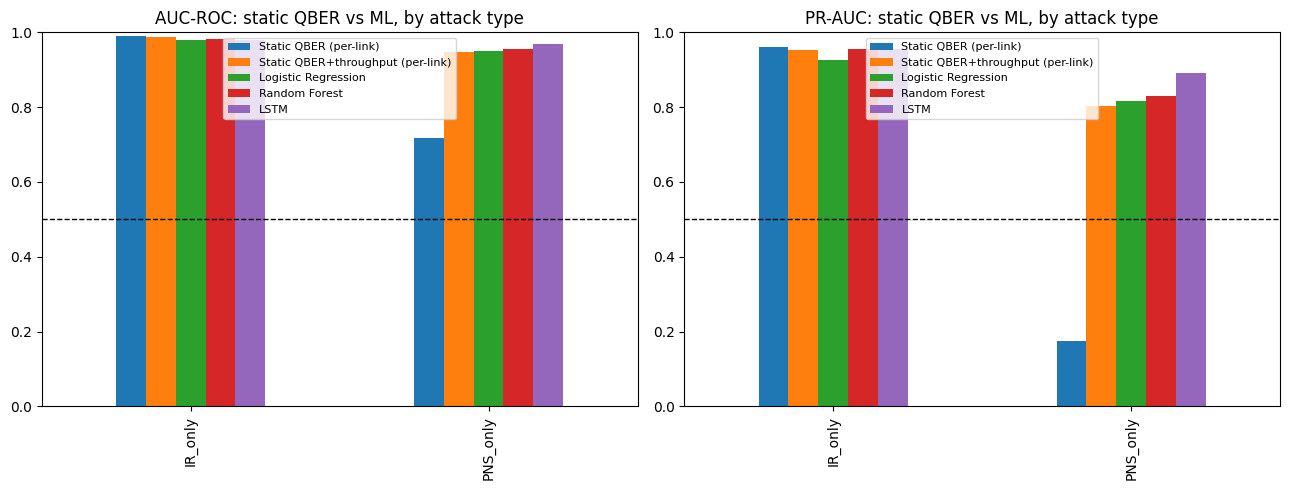

Saved comparison table and chart to /content/drive/MyDrive/Capstone


In [20]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_df = comparison_df.reset_index()

for ax, metric in zip(axes, ["AUC-ROC", "PR-AUC"]):
    pivot = plot_df[plot_df["split"] != "ALL"].pivot(index="split", columns="method", values=metric)
    pivot = pivot[list(methods.keys())]  # keep consistent method order
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"{metric}: static QBER vs ML, by attack type")
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="k", linestyle="--", linewidth=1)
    ax.legend(fontsize=8)
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, "final_comparison_chart.png"), dpi=130)
plt.show()

comparison_df.to_csv(os.path.join(DRIVE_DIR, "final_comparison_table.csv"))
print(f"Saved comparison table and chart to {DRIVE_DIR}")



## 13. Notes / caveats for writeup

- **PNS_only / IR_only splits are evaluated against the same clean-tick
  population** (all `attack_kind == "none"` ticks in the test set), each
  compared to just its own attack subset -- this is the same convention the
  EDA used, so numbers here are directly comparable to the EDA's AUC tables.
- The static-QBER baseline here is **per-link calibrated** (z-scored within
  each run), which is already a fairer/stronger baseline than a single
  global magic-number threshold across all distances -- if ML still beats
  it, that's a meaningfully stronger claim than beating a strawman global
  threshold.
- Random Forest's feature importances (section 10) are worth reporting
  alongside AUC numbers -- they show *which* features the model is actually
  relying on, which is good corroborating evidence (or a red flag, if it
  turns out to be leaning entirely on one feature that shouldn't matter).
- If LSTM doesn't clearly beat the tabular baselines, that's a legitimate
  result to report, not a failure -- it would mean the temporal window isn't
  adding information beyond a single normalized snapshot, which is itself
  informative for the writeup (and worth trying a longer `WINDOW_LEN` or
  smaller `STRIDE` before concluding that).
- `WINDOW_LEN`, `STRIDE`, `N_EPOCHS`, `FEATURE_COLS`, and the LSTM's
  `hidden_size`/`num_layers` are all left as easily-editable constants above
  for further tuning/ablation.


## 14. Follow-up: attributing the PNS signal (sifted_rate vs decoy-state features)

The Random Forest's feature importances (section 10) showed
`sifted_rate_roll_mean_30_z` essentially tied with `qber_roll_mean_30_z` for
most important, well ahead of the decoy-state features
(`decoy_anomaly_roll_mean_30_z`, `y1_lower_roll_mean_30_z`). That matters for
how the PNS result gets explained: is the PNS detectability coming from the
decoy-state analysis this project set out to test, or mostly from a simpler
throughput drop (PNS blocks single photons, so fewer get sifted)? Both are
real, legitimate signals, but they're different claims -- worth knowing
which one is actually carrying the result before writing it up.

This section: (1) computes each feature's own standalone AUC vs PNS, and
(2) retrains both the LSTM and Random Forest **without**
`sifted_rate_roll_mean_30`, to see how much of the PNS advantage survives.

In [21]:

print("=== Standalone AUC per feature (test set, last timestep) ===")
print(f"{'feature':<34}{'AUC vs PNS':>14}{'AUC vs IR':>14}{'AUC vs ALL':>14}")

pns_mask_tab = np.isin(test_ak, ["none", "pns_like"])
ir_mask_tab  = np.isin(test_ak, ["none", "intercept_resend"])
all_mask_tab = np.ones(len(y_te_tab), dtype=bool)

def _feat_auc(x, mask):
    yy, xx = y_te_tab[mask], x[mask]
    if len(np.unique(yy)) < 2:
        return np.nan
    a = roc_auc_score(yy, xx)
    return max(a, 1 - a)

feat_auc_rows = []
for i, col in enumerate(Z_COLS):
    x_col = X_te_tab[:, i]
    a_pns = _feat_auc(x_col, pns_mask_tab)
    a_ir  = _feat_auc(x_col, ir_mask_tab)
    a_all = _feat_auc(x_col, all_mask_tab)
    feat_auc_rows.append((col, a_pns, a_ir, a_all))
    print(f"{col:<34}{a_pns:>14.4f}{a_ir:>14.4f}{a_all:>14.4f}")

feat_auc_df = pd.DataFrame(feat_auc_rows, columns=["feature", "auc_pns", "auc_ir", "auc_all"])
feat_auc_df = feat_auc_df.sort_values("auc_pns", ascending=False).reset_index(drop=True)
feat_auc_df


=== Standalone AUC per feature (test set, last timestep) ===
feature                               AUC vs PNS     AUC vs IR    AUC vs ALL
observed_qber_z                           0.5770        0.9501        0.7831
qber_roll_mean_30_z                       0.7177        0.9891        0.8676
qber_roll_std_30_z                        0.6107        0.9407        0.7930
qber_cv_30_z                              0.5227        0.9282        0.7467
qber_slope_30_z                           0.5005        0.5083        0.5048
decoy_anomaly_roll_mean_30_z              0.6504        0.5036        0.5693
y1_lower_roll_mean_30_z                   0.8509        0.5087        0.6619
secure_key_rate_roll_mean_30_z            0.5002        0.5010        0.5006
sifted_rate_roll_mean_30_z                0.9590        0.5128        0.7126


,feature,auc_pns,auc_ir,auc_all
0,sifted_rate_roll_mean_30_z,0.959017,0.512816,0.712551
1,y1_lower_roll_mean_30_z,0.850866,0.508709,0.661870
2,qber_roll_mean_30_z,0.717681,0.989120,0.867614
3,decoy_anomaly_roll_mean_30_z,0.650393,0.503616,0.569319
4,qber_roll_std_30_z,0.610660,0.940707,0.792966
5,observed_qber_z,0.576991,0.950064,0.783064
6,qber_cv_30_z,0.522691,0.928198,0.746679
7,qber_slope_30_z,0.500454,0.508347,0.504814
8,secure_key_rate_roll_mean_30_z,0.500235,0.500958,0.500634


In [22]:

ABLATE_FEATURE = "sifted_rate_roll_mean_30_z"
keep_idx = [i for i, c in enumerate(Z_COLS) if c != ABLATE_FEATURE]
ablated_cols = [Z_COLS[i] for i in keep_idx]
print(f"Ablated feature set ({len(ablated_cols)} features, dropped {ABLATE_FEATURE}):")
print(ablated_cols)

train_feat_abl = train_feat[:, keep_idx]
test_feat_abl  = test_feat[:, keep_idx]

tr_ds_abl = QKDWindowDataset(train_feat_abl, train_starts[~is_val], train_ends[~is_val], train_labels[~is_val])
va_ds_abl = QKDWindowDataset(train_feat_abl, train_starts[is_val], train_ends[is_val], train_labels[is_val])
te_ds_abl = QKDWindowDataset(test_feat_abl, test_starts, test_ends, test_labels)

tr_loader_abl = DataLoader(tr_ds_abl, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
va_loader_abl = DataLoader(va_ds_abl, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
te_loader_abl = DataLoader(te_ds_abl, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)


Ablated feature set (8 features, dropped sifted_rate_roll_mean_30_z):
['observed_qber_z', 'qber_roll_mean_30_z', 'qber_roll_std_30_z', 'qber_cv_30_z', 'qber_slope_30_z', 'decoy_anomaly_roll_mean_30_z', 'y1_lower_roll_mean_30_z', 'secure_key_rate_roll_mean_30_z']


In [23]:



def train_lstm_model(tr_loader, va_loader, tr_ds, n_features, pos_weight,
                      n_epochs=15, patience=3, lr=1e-3, ckpt_path=None, seed=SEED):
    torch.manual_seed(seed)
    model = LSTMDetector(n_features=n_features).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=1)
    scaler = torch.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    best_val_auc, best_state, bad_epochs = -1.0, None, 0
    for epoch in range(n_epochs):
        model.train()
        t0 = time.time()
        train_loss = 0.0
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            opt.zero_grad()
            with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
                out = model(xb)
                loss = criterion(out, yb)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            train_loss += loss.item() * len(yb)
        train_loss /= len(tr_ds)

        val_logits, val_y = run_eval_loader(model, va_loader)
        val_auc = roc_auc_score(val_y, val_logits)
        scheduler.step(val_auc)
        print(f"epoch {epoch+1:2d}/{n_epochs}  train_loss={train_loss:.4f}  "
              f"val_auc={val_auc:.4f}  time={time.time()-t0:.1f}s")

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if ckpt_path:
                torch.save(best_state, ckpt_path)
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model, best_val_auc


print("--- retraining LSTM WITHOUT sifted_rate_roll_mean_30 ---")
ABL_CKPT_PATH = os.path.join(DRIVE_DIR, "best_lstm_model_ablated.pt")
model_abl, best_val_auc_abl = train_lstm_model(
    tr_loader_abl, va_loader_abl, tr_ds_abl, n_features=len(ablated_cols),
    pos_weight=pos_weight, n_epochs=N_EPOCHS, patience=PATIENCE, lr=LR, ckpt_path=ABL_CKPT_PATH,
)
print(f"ablated model best val AUC: {best_val_auc_abl:.4f}")

test_logits_abl, test_y_abl = run_eval_loader(model_abl, te_loader_abl)
test_probs_lstm_abl = 1 / (1 + np.exp(-test_logits_abl))
lstm_results_abl = evaluate_probs(test_probs_lstm_abl, test_y_abl, test_ak)
print("\n=== LSTM (ablated: no sifted_rate) ===")
for k, v in lstm_results_abl.items():
    print(f"{k:<10}", v)


--- retraining LSTM WITHOUT sifted_rate_roll_mean_30 ---
epoch  1/15  train_loss=0.3304  val_auc=0.9808  time=4.2s
epoch  2/15  train_loss=0.2388  val_auc=0.9799  time=4.3s
epoch  3/15  train_loss=0.2300  val_auc=0.9797  time=6.1s
epoch  4/15  train_loss=0.2175  val_auc=0.9812  time=5.1s
epoch  5/15  train_loss=0.2142  val_auc=0.9803  time=4.1s
epoch  6/15  train_loss=0.2132  val_auc=0.9800  time=4.8s
epoch  7/15  train_loss=0.2097  val_auc=0.9809  time=6.6s
early stopping at epoch 7
ablated model best val AUC: 0.9812

=== LSTM (ablated: no sifted_rate) ===
ALL        {'auc': np.float64(0.9693145669733961), 'ap': np.float64(0.9265969156879791), 'f1': 0.8195097380792478, 'n': 143950, 'pos': 10828}
PNS_only   {'auc': np.float64(0.9518314091275977), 'ap': np.float64(0.8422278347149225), 'f1': 0.6701226034723936, 'n': 137969, 'pos': 4847}
IR_only    {'auc': np.float64(0.9834829110761524), 'ap': np.float64(0.9587635568690055), 'f1': 0.7635021804763502, 'n': 139103, 'pos': 5981}


In [24]:

# same ablation for Random Forest -- cheap, and a good corroborating check
# since it doesn't share any training instability with the LSTM
abl_feat_idx = [i for i, c in enumerate(Z_COLS) if c != ABLATE_FEATURE]
X_tr_tab_abl = X_tr_tab[:, abl_feat_idx]
X_te_tab_abl = X_te_tab[:, abl_feat_idx]

rf_abl = RandomForestClassifier(
    n_estimators=200, max_depth=12, class_weight="balanced", n_jobs=-1, random_state=SEED
)
rf_abl.fit(X_tr_tab_abl, y_tr_tab)
rf_probs_abl = rf_abl.predict_proba(X_te_tab_abl)[:, 1]
rf_results_abl = evaluate_probs(rf_probs_abl, y_te_tab, test_ak)
print("=== Random Forest (ablated: no sifted_rate) ===")
for k, v in rf_results_abl.items():
    print(f"{k:<10}", v)

feat_importance_abl = pd.Series(rf_abl.feature_importances_, index=ablated_cols).sort_values(ascending=False)
print("\nAblated Random Forest feature importances (with sifted_rate removed):")
print(feat_importance_abl)


=== Random Forest (ablated: no sifted_rate) ===
ALL        {'auc': np.float64(0.9525325397496813), 'ap': np.float64(0.8861128480594995), 'f1': 0.858041683051514, 'n': 143950, 'pos': 10828}
PNS_only   {'auc': np.float64(0.9136754067968516), 'ap': np.float64(0.7281666026866991), 'f1': 0.7108213223518646, 'n': 137969, 'pos': 4847}
IR_only    {'auc': np.float64(0.9840223447024259), 'ap': np.float64(0.9572811999895743), 'f1': 0.9073446327683616, 'n': 139103, 'pos': 5981}

Ablated Random Forest feature importances (with sifted_rate removed):
qber_roll_mean_30_z               0.323740
y1_lower_roll_mean_30_z           0.285933
observed_qber_z                   0.141333
qber_roll_std_30_z                0.098761
decoy_anomaly_roll_mean_30_z      0.074761
qber_cv_30_z                      0.056799
qber_slope_30_z                   0.013529
secure_key_rate_roll_mean_30_z    0.005144
dtype: float64


In [25]:
ablation_rows = []
for method, full_res, abl_res in [
    ("LSTM", lstm_results, lstm_results_abl),
    ("Random Forest", rf_results, rf_results_abl),
]:
    for split in ["ALL", "PNS_only", "IR_only"]:
        f, a = full_res.get(split), abl_res.get(split)
        if f is None or a is None:
            continue
        ablation_rows.append({
            "method": method, "split": split,
            "AUC (full)": f["auc"], "AUC (no sifted_rate)": a["auc"], "AUC drop": f["auc"] - a["auc"],
            "PR-AUC (full)": f["ap"], "PR-AUC (no sifted_rate)": a["ap"], "PR-AUC drop": f["ap"] - a["ap"],
        })

ablation_df = pd.DataFrame(ablation_rows).set_index(["split", "method"]).sort_index()
ablation_df

AUC (full)  AUC (no sifted_rate)  AUC drop  \
split    method                                                      
ALL      LSTM             0.974594              0.969315  0.005279   
         Random Forest    0.970253              0.952533  0.017721   
IR_only  LSTM             0.979915              0.983483 -0.003568   
         Random Forest    0.981466              0.984022 -0.002556   
PNS_only LSTM             0.968027              0.951831  0.016195   
         Random Forest    0.956417              0.913675  0.042741   

                        PR-AUC (full)  PR-AUC (no sifted_rate)  PR-AUC drop  
split    method                                                              
ALL      LSTM                0.941234                 0.926597     0.014637  
         Random Forest       0.921590                 0.886113     0.035477  
IR_only  LSTM                0.954813                 0.958764    -0.003950  
         Random Forest       0.954535                 0.957281    -0.002746  
PNS_only LSTM                0.891903                 0.842228     0.049675  
         Random Forest       0.830605                 0.728167     0.102438


### Interpreting the ablation

- **Small AUC/PR-AUC drop on `PNS_only` when `sifted_rate` is removed** ->
  the decoy-state features (`y1_lower`, `decoy_anomaly`) and rolled QBER
  pattern are carrying most of the PNS signal on their own -- the original
  decoy-state framing of the result holds up well.
- **Large drop** -> `sifted_rate` (a simple throughput/key-rate monitor,
  not a decoy-state-specific quantity) was doing most of the work. Still a
  legitimate ML-beats-static-QBER result, but the honest framing changes to
  "ML exploits multiple observable signals including throughput," not
  specifically "decoy-state analysis via ML." Worth stating explicitly
  either way rather than picking whichever framing sounds better -- the
  `feat_auc_df` table above (each feature's own standalone AUC) gives the
  supporting evidence for whichever conclusion the ablation points to.
- Compare `IR_only` in the same table as a sanity check: IR shouldn't
  depend much on `sifted_rate` at all (it's a QBER-driven attack), so the
  IR row's AUC drop should stay small regardless of what the PNS row shows.



## 15. GPU note: what actually needs the H100

**Two separate workloads here, with different bottlenecks:**

- **Dataset generation (`generate_qkd_dataset.py`, run outside this notebook)**
  is pure NumPy/Pandas -- it is **CPU-bound**, and a GPU (T4, H100, or
  otherwise) gives essentially zero speedup here. Run this on a normal
  laptop or your college's CPU nodes; there's no benefit to spending H100
  time on it. Each seed's generation is independent of every other seed, so
  if your cluster lets you run several CPU jobs in parallel, generating
  multiple seeds' datasets at once (one process per seed) is the actual
  time-saver for this part, not the GPU.
- **This notebook (LSTM training, once per seed)** *does* benefit from GPU,
  more so now that training gets repeated once per seed. A T4 works fine; an
  H100 makes each seed's LSTM training noticeably faster and lets you use a
  bigger `BATCH_SIZE` comfortably if you want. Random Forest and Logistic
  Regression stay CPU-only no matter what GPU is attached -- that's normal.

**Recommendation:** generate all seed datasets on CPU first (laptop or
college CPU cluster), upload them to Drive, *then* open this notebook on
whichever GPU runtime you have (T4 or H100, both fine) for the loop below.

## 16. Step 4: Multi-seed robustness check (full scale)

Repeats the section 1-11 pipeline (normalize -> window -> LSTM + RF ->
static baselines) once per random seed, so results can be reported as
**mean +/- std across seeds** instead of a single run's numbers -- this is
what addresses the "we only tried one seed" caveat.

**Before running this section**, generate one dataset per seed *outside this
notebook*, on CPU (see GPU note above):

```python
# run in a plain Python script / terminal, NOT in this notebook -- once, covers all seeds
from generate_qkd_dataset import build_dataset
import shutil

for seed in [1, 2, 3, 4, 5, 6, 7]:   # edit this list -- add more entries for more than 5 seeds
    build_dataset(n_runs=100, duration_s=86_400, seed=seed)
    shutil.move("qkd_train_decoy.csv", f"qkd_train_decoy_seed{seed}.csv")
    shutil.move("qkd_test_decoy.csv",  f"qkd_test_decoy_seed{seed}.csv")
```

Then upload each `qkd_train_decoy_seed{N}.csv` / `qkd_test_decoy_seed{N}.csv`
pair to **`MyDrive/Capstone/multiseed/`**. The cells below expect exactly
that folder and naming pattern.

**Do not delete or overwrite the original `qkd_train_decoy.csv` /
`qkd_test_decoy.csv`** (seed 42, used in sections 1-14 above) -- those stay
untouched; this section adds a multi-seed robustness check on top, it
doesn't replace the main result.


In [26]:
SEEDS = [1, 2, 3, 4, 5, 6, 7]   # edit freely -- "more than 5 seeds" just means add more entries here

MULTISEED_DRIVE_DIR = os.path.join(DRIVE_DIR, "multiseed")
MULTISEED_LOCAL_DIR = os.path.join(LOCAL_DIR, "multiseed")
os.makedirs(MULTISEED_LOCAL_DIR, exist_ok=True)

missing = []
for seed in SEEDS:
    for fname in [f"qkd_train_decoy_seed{seed}.csv", f"qkd_test_decoy_seed{seed}.csv"]:
        if not os.path.exists(os.path.join(MULTISEED_DRIVE_DIR, fname)):
            missing.append(fname)

if missing:
    print("Missing seed dataset files on Drive -- generate these first (see markdown above):")
    for f in missing:
        print(" -", os.path.join(MULTISEED_DRIVE_DIR, f))
    print("\nNot running the multi-seed loop until all files are present.")
else:
    print(f"All {len(SEEDS)} seed datasets found on Drive. Ready to run.")


All 7 seed datasets found on Drive. Ready to run.


In [27]:
def run_full_pipeline_for_seed(seed, verbose=True):
    """Runs the full section 1-11 pipeline (normalize -> window -> LSTM/RF/static
    baselines) for one seed's dataset, reusing FEATURE_COLS, WINDOW_LEN, STRIDE,
    N_EPOCHS etc. already set above. Returns a dict of per-method results."""
    t_start = time.time()

    # --- copy this seed's CSVs to local disk (same pattern as section 2) ---
    train_fname = f"qkd_train_decoy_seed{seed}.csv"
    test_fname  = f"qkd_test_decoy_seed{seed}.csv"
    train_src = os.path.join(MULTISEED_DRIVE_DIR, train_fname)
    test_src  = os.path.join(MULTISEED_DRIVE_DIR, test_fname)
    train_dst = os.path.join(MULTISEED_LOCAL_DIR, train_fname)
    test_dst  = os.path.join(MULTISEED_LOCAL_DIR, test_fname)
    shutil.copy(train_src, train_dst)
    shutil.copy(test_src, test_dst)

    tr = pd.read_csv(train_dst, dtype=DTYPE_MAP)
    te = pd.read_csv(test_dst, dtype=DTYPE_MAP)
    assert tr["hardware"].unique().tolist() == ["cooled"]
    assert te["hardware"].unique().tolist() == ["uncooled"]

    # --- normalize (reuses robust_normalize_per_run from section 4) ---
    tr = robust_normalize_per_run(tr, FEATURE_COLS)
    te = robust_normalize_per_run(te, FEATURE_COLS)

    # --- window (reuses build_windows from section 5) ---
    s_feat, s_starts, s_ends, s_labels, s_ak, s_rid = build_windows(tr, Z_COLS, WINDOW_LEN, STRIDE)
    t_feat, t_starts, t_ends, t_labels, t_ak, t_rid = build_windows(te, Z_COLS, WINDOW_LEN, STRIDE)

    rng_s = np.random.default_rng(seed)
    run_ids_s = np.unique(s_rid)
    val_ids_s = rng_s.choice(run_ids_s, size=max(1, len(run_ids_s) // 5), replace=False)
    is_val_s = np.isin(s_rid, val_ids_s)

    tr_ds_s = QKDWindowDataset(s_feat, s_starts[~is_val_s], s_ends[~is_val_s], s_labels[~is_val_s])
    va_ds_s = QKDWindowDataset(s_feat, s_starts[is_val_s], s_ends[is_val_s], s_labels[is_val_s])
    te_ds_s = QKDWindowDataset(t_feat, t_starts, t_ends, t_labels)

    tr_loader_s = DataLoader(tr_ds_s, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    va_loader_s = DataLoader(va_ds_s, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
    te_loader_s = DataLoader(te_ds_s, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

    # --- LSTM (reuses train_lstm_model from section 14 / LSTMDetector from section 7) ---
    pos_frac_s = s_labels[~is_val_s].mean()
    pos_weight_s = torch.tensor([(1 - pos_frac_s) / pos_frac_s], device=DEVICE)
    ckpt_s = os.path.join(MULTISEED_DRIVE_DIR, f"best_lstm_seed{seed}.pt")
    model_s, best_val_auc_s = train_lstm_model(
        tr_loader_s, va_loader_s, tr_ds_s, n_features=len(Z_COLS),
        pos_weight=pos_weight_s, n_epochs=N_EPOCHS, patience=PATIENCE, lr=LR,
        ckpt_path=ckpt_s, seed=seed,
    )
    test_logits_s, test_y_s = run_eval_loader(model_s, te_loader_s)
    lstm_probs_s = 1 / (1 + np.exp(-test_logits_s))
    lstm_res_s = evaluate_probs(lstm_probs_s, test_y_s, t_ak)

    # --- Random Forest (last timestep only, same convention as section 10) ---
    X_tr_s = s_feat[s_ends[~is_val_s] - 1]
    y_tr_s = s_labels[~is_val_s]
    X_te_s = t_feat[t_ends - 1]
    y_te_s = t_labels

    rf_s = RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight="balanced", n_jobs=-1, random_state=seed
    ).fit(X_tr_s, y_tr_s)
    rf_res_s = evaluate_probs(rf_s.predict_proba(X_te_s)[:, 1], y_te_s, t_ak)

    # --- static QBER-only and combined QBER+throughput baselines (same as sections 11-12) ---
    qber_idx_s = Z_COLS.index("qber_roll_mean_30_z")
    sifted_idx_s = Z_COLS.index("sifted_rate_roll_mean_30_z")
    qber_z_s = X_te_s[:, qber_idx_s]
    sifted_z_s = X_te_s[:, sifted_idx_s]

    def _score_results(score):
        out = {}
        for name, ak_mask in [
            ("ALL", np.ones(len(y_te_s), dtype=bool)),
            ("PNS_only", np.isin(t_ak, ["none", "pns_like"])),
            ("IR_only", np.isin(t_ak, ["none", "intercept_resend"])),
        ]:
            yy, xx = y_te_s[ak_mask], score[ak_mask]
            if len(np.unique(yy)) < 2:
                out[name] = None
                continue
            out[name] = dict(auc=roc_auc_score(yy, xx), ap=average_precision_score(yy, xx),
                              n=len(yy), pos=int(yy.sum()))
        return out

    static_res_s = _score_results(qber_z_s)
    combined_res_s = _score_results(np.maximum(qber_z_s, -sifted_z_s))

    # --- clean up this seed's local CSVs (keeps Colab disk usage bounded across many seeds) ---
    os.remove(train_dst)
    os.remove(test_dst)

    if verbose:
        print(f"[seed {seed}] done in {time.time()-t_start:.0f}s  "
              f"LSTM best_val_auc={best_val_auc_s:.4f}")

    return dict(seed=seed, static=static_res_s, combined=combined_res_s,
                rf=rf_res_s, lstm=lstm_res_s)


In [28]:
MULTISEED_RESULTS_CSV = os.path.join(MULTISEED_DRIVE_DIR, "multiseed_results_raw.csv")

# Resume support: if this crashes/disconnects partway, rerunning this cell
# picks up from the last completed seed instead of starting over.
if os.path.exists(MULTISEED_RESULTS_CSV):
    done_df = pd.read_csv(MULTISEED_RESULTS_CSV)
    done_seeds = set(done_df["seed"].unique().tolist())
    print(f"Found existing results for seeds: {sorted(done_seeds)}")
else:
    done_df = pd.DataFrame()
    done_seeds = set()

all_rows = done_df.to_dict("records")

for seed in SEEDS:
    if seed in done_seeds:
        print(f"[seed {seed}] already done, skipping")
        continue
    print(f"\n========== SEED {seed} ==========")
    result = run_full_pipeline_for_seed(seed)

    for method_name, res in [
        ("Static QBER (per-link)", result["static"]),
        ("Static QBER+throughput (per-link)", result["combined"]),
        ("Random Forest", result["rf"]),
        ("LSTM", result["lstm"]),
    ]:
        for split in ["ALL", "PNS_only", "IR_only"]:
            r = res.get(split)
            if r is None:
                continue
            all_rows.append({
                "seed": seed, "method": method_name, "split": split,
                "auc": r["auc"], "pr_auc": r["ap"],
            })

    # save after EVERY seed, not just at the end -- protects against session
    # disconnects during a multi-hour multi-seed run
    pd.DataFrame(all_rows).to_csv(MULTISEED_RESULTS_CSV, index=False)
    print(f"[seed {seed}] results saved to {MULTISEED_RESULTS_CSV}")

final_seeds_done = sorted(pd.read_csv(MULTISEED_RESULTS_CSV)["seed"].unique())
print(f"\nSeeds now in results file: {final_seeds_done}")
if set(final_seeds_done) >= set(SEEDS):
    print("All requested seeds complete.")
else:
    print(f"Still missing: {sorted(set(SEEDS) - set(final_seeds_done))} -- rerun this cell to continue.")



========== SEED 1 ==========
epoch  1/15  train_loss=0.2944  val_auc=0.9940  time=6.1s
epoch  2/15  train_loss=0.2122  val_auc=0.9929  time=5.7s
epoch  3/15  train_loss=0.2052  val_auc=0.9938  time=5.5s
epoch  4/15  train_loss=0.1996  val_auc=0.9937  time=5.6s
early stopping at epoch 4
[seed 1] done in 332s  LSTM best_val_auc=0.9940
[seed 1] results saved to /content/drive/MyDrive/Capstone/multiseed/multiseed_results_raw.csv

========== SEED 2 ==========
epoch  1/15  train_loss=0.2827  val_auc=0.9824  time=5.0s
epoch  2/15  train_loss=0.1945  val_auc=0.9836  time=4.2s
epoch  3/15  train_loss=0.1963  val_auc=0.9836  time=4.7s
epoch  4/15  train_loss=0.1986  val_auc=0.9824  time=6.3s
epoch  5/15  train_loss=0.1877  val_auc=0.9828  time=5.6s
epoch  6/15  train_loss=0.1810  val_auc=0.9833  time=5.5s
early stopping at epoch 6
[seed 2] done in 369s  LSTM best_val_auc=0.9836
[seed 2] results saved to /content/drive/MyDrive/Capstone/multiseed/multiseed_results_raw.csv

========== SEED 3 =====

In [29]:
multiseed_df = pd.read_csv(MULTISEED_RESULTS_CSV)

summary_df = (
    multiseed_df.groupby(["method", "split"])[["auc", "pr_auc"]]
    .agg(["mean", "std", "count"])
)
summary_df.columns = ["_".join(c) for c in summary_df.columns]
summary_df = summary_df.round(4)
n_seeds_agg = multiseed_df["seed"].nunique()
seeds_agg_list = sorted(multiseed_df["seed"].unique())
print(f"Aggregated over {n_seeds_agg} seeds: {seeds_agg_list}")
summary_df


Aggregated over 7 seeds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


auc_mean  auc_std  auc_count  \
method                            split                                    
LSTM                              ALL         0.9619   0.0047          7   
                                  IR_only     0.9777   0.0049          7   
                                  PNS_only    0.9474   0.0062          7   
Random Forest                     ALL         0.9534   0.0053          7   
                                  IR_only     0.9751   0.0041          7   
                                  PNS_only    0.9332   0.0077          7   
Static QBER (per-link)            ALL         0.8288   0.0165          7   
                                  IR_only     0.9836   0.0042          7   
                                  PNS_only    0.6855   0.0312          7   
Static QBER+throughput (per-link) ALL         0.9530   0.0059          7   
                                  IR_only     0.9802   0.0040          7   
                                  PNS_only    0.9278   0.0096          7   

                                            pr_auc_mean  pr_auc_std  \
method                            split                               
LSTM                              ALL            0.9151      0.0138   
                                  IR_only        0.9441      0.0123   
                                  PNS_only       0.8527      0.0234   
Random Forest                     ALL            0.8909      0.0151   
                                  IR_only        0.9354      0.0120   
                                  PNS_only       0.8005      0.0294   
Static QBER (per-link)            ALL            0.6369      0.0227   
                                  IR_only        0.9472      0.0087   
                                  PNS_only       0.1543      0.0355   
Static QBER+throughput (per-link) ALL            0.8858      0.0155   
                                  IR_only        0.9396      0.0096   
                                  PNS_only       0.7803      0.0300   

                                            pr_auc_count  
method                            split                   
LSTM                              ALL                  7  
                                  IR_only              7  
                                  PNS_only             7  
Random Forest                     ALL                  7  
                                  IR_only              7  
                                  PNS_only             7  
Static QBER (per-link)            ALL                  7  
                                  IR_only              7  
                                  PNS_only             7  
Static QBER+throughput (per-link) ALL                  7  
                                  IR_only              7  
                                  PNS_only             7

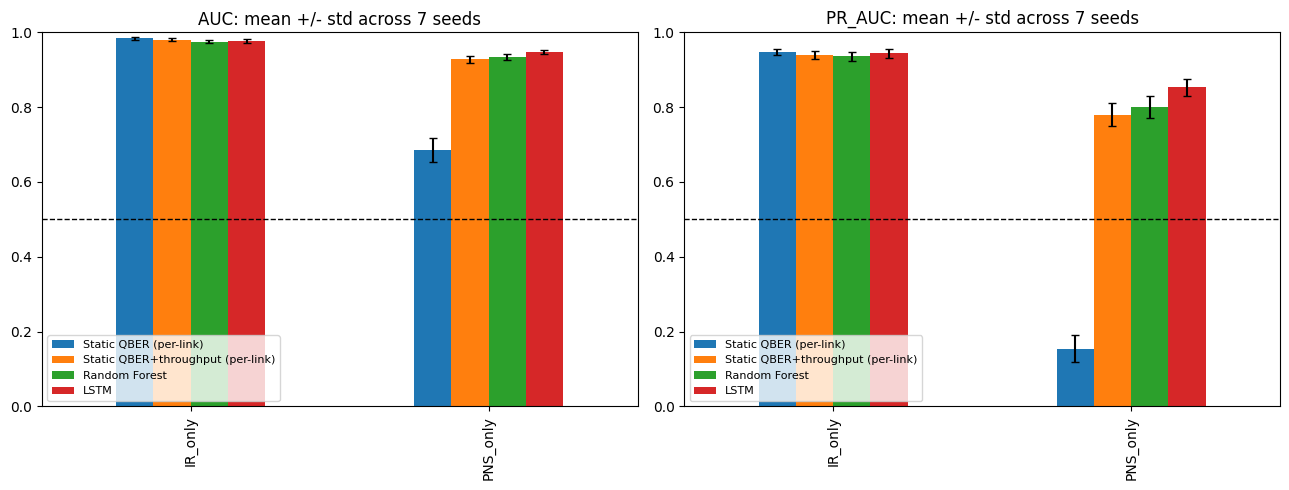

Saved multi-seed summary table and chart to /content/drive/MyDrive/Capstone/multiseed


In [30]:
method_order = ["Static QBER (per-link)", "Static QBER+throughput (per-link)",
                 "Random Forest", "LSTM"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_data = summary_df.reset_index()
plot_data = plot_data[plot_data["split"] != "ALL"]

for ax, metric in zip(axes, ["auc", "pr_auc"]):
    pivot_mean = plot_data.pivot(index="split", columns="method", values=f"{metric}_mean")
    pivot_std  = plot_data.pivot(index="split", columns="method", values=f"{metric}_std")
    cols = [m for m in method_order if m in pivot_mean.columns]
    pivot_mean = pivot_mean[cols]
    pivot_std  = pivot_std[cols]

    pivot_mean.plot(kind="bar", yerr=pivot_std, ax=ax, capsize=3)
    n_seeds_plot = multiseed_df["seed"].nunique()
    ax.set_title(f"{metric.upper()}: mean +/- std across {n_seeds_plot} seeds")
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="k", linestyle="--", linewidth=1)
    ax.legend(fontsize=8)
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig(os.path.join(MULTISEED_DRIVE_DIR, "multiseed_comparison_chart.png"), dpi=130)
plt.show()

summary_df.to_csv(os.path.join(MULTISEED_DRIVE_DIR, "multiseed_summary_table.csv"))
print(f"Saved multi-seed summary table and chart to {MULTISEED_DRIVE_DIR}")


### What to record from this section for the paper

- Report every headline number as **mean +/- std** (from `summary_df` above),
  not a single seed's value -- e.g. "LSTM PR-AUC on PNS: 0.89 +/- 0.02
  (N=7 seeds)" instead of just "0.89".
- If std is small relative to the gap between methods (e.g. LSTM PNS AUC
  0.97 +/- 0.01 vs static QBER 0.72 +/- 0.03), the core finding is robust to
  reseeding -- safe to report as-is.
- If std is large enough that method rankings could flip between seeds
  (e.g. LSTM and Random Forest overlap within 1 std on PNS PR-AUC), say so
  explicitly rather than reporting whichever seed looks best -- that's
  exactly the kind of thing caveat #4 exists to catch.
- `multiseed_results_raw.csv` (per-seed, per-method, per-split numbers) is
  the raw evidence behind `summary_df` -- keep it, a reviewer may ask for it.
- This section only reruns LSTM/RF/static baselines per seed, not the
  Logistic Regression baseline from section 10 -- add it to
  `run_full_pipeline_for_seed` the same way as Random Forest if you want it
  included in the multi-seed table too.
